In [1]:
import os
import glob
import numpy as np
import scipy.io as sio
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

/home/filipe/miniconda3/envs/redes_grafos/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GestureSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, pre_transform=None):
        super(GestureSequenceDataset, self).__init__(root_dir, transform, pre_transform)
        self.root_dir = root_dir
        self.mat_files = glob.glob(os.path.join(root_dir, '*.mat'))
        
        self.label_to_id = {} 
        self.current_id = 0 
        
        self.data_list = self._process_all_files()

    def _process_all_files(self):
        all_sequences = []
        
        for filepath in self.mat_files:
            mat_data = sio.loadmat(filepath, squeeze_me=True, struct_as_record=False)
            video = mat_data['Video']
            frames = np.atleast_1d(video.Frames)
            
            if not hasattr(video, 'Labels'):
                continue
                
            labels = np.atleast_1d(video.Labels)
            
            for segment in labels:
                nome_gesto = segment.Name
                start_idx = segment.Begin - 1
                end_idx = segment.End 
                
                frames_do_gesto = frames[start_idx:end_idx]
                
                sequencia_coordenadas = []
                
                for frame in frames_do_gesto:
                    if hasattr(frame, 'Skeleton') and hasattr(frame.Skeleton, 'PixelPosition'):
                        pos = frame.Skeleton.PixelPosition
                        if isinstance(pos, np.ndarray) and pos.ndim == 2 and pos.shape[0] == 20:
                            sequencia_coordenadas.append(pos)
                
                if len(sequencia_coordenadas) > 0:
                    
                    x_seq = torch.tensor(np.array(sequencia_coordenadas), dtype=torch.float)
                    
                    centro_de_massa = x_seq.mean(dim=1, keepdim=True) 

                    x_seq = x_seq - centro_de_massa

                    x_seq = x_seq / (x_seq.std() + 1e-5)

                    if nome_gesto not in self.label_to_id:
                        self.label_to_id[nome_gesto] = self.current_id
                        self.current_id += 1
                        
                    y_val = self.label_to_id[nome_gesto]
                    y = torch.tensor([y_val], dtype=torch.long)
                    
                    empty_edge_index = torch.empty((2, 0), dtype=torch.long)
                    
                    graph_data = Data(x=x_seq, edge_index=empty_edge_index, y=y)
                    all_sequences.append(graph_data)
                        
        return all_sequences

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

In [3]:
dataset = GestureSequenceDataset(root_dir='apenas_mats_train')

In [5]:
import torch
from torch.utils.data import random_split

total_amostras = len(dataset)

tamanho_treino = int(0.70 * total_amostras)
tamanho_val = int(0.15 * total_amostras)
tamanho_teste = total_amostras - tamanho_treino - tamanho_val 

print(f"Divisão: Treino ({tamanho_treino}), Validação ({tamanho_val}), Teste ({tamanho_teste})")

dataset_treino, dataset_val, dataset_teste = random_split(
    dataset, 
    [tamanho_treino, tamanho_val, tamanho_teste],
)

Divisão: Treino (5427), Validação (1163), Teste (1164)


In [6]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def preencher_lote_collate_fn(lista_de_grafos):
    xs = [grafo.x for grafo in lista_de_grafos] 
    ys = [grafo.y for grafo in lista_de_grafos] 
    
    tamanhos_reais = torch.tensor([len(x) for x in xs], dtype=torch.long)
    
    x_padded = pad_sequence(xs, batch_first=True, padding_value=0.0)
    
    y_batched = torch.cat(ys)
    
    return x_padded, y_batched, tamanhos_reais


loader_treino = DataLoader(
    dataset_treino, 
    batch_size=32, 
    shuffle=True, 
    collate_fn=preencher_lote_collate_fn
)

loader_val = DataLoader(dataset_val, batch_size=32, shuffle=False, collate_fn=preencher_lote_collate_fn)
loader_teste = DataLoader(dataset_teste, batch_size=32, shuffle=False, collate_fn=preencher_lote_collate_fn)

In [16]:
def sharp_sigmoid(x, sharpness=50, threshold=0.1):
    return torch.sigmoid(sharpness * (x - threshold))

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv

class GestureGSLModel(nn.Module):
    def __init__(self, num_nodes=20, in_features=2, num_classes=20):
        super().__init__()
        
        adj = torch.rand((num_nodes, num_nodes)) * 0.04 + 0.01
        self.adj_param = nn.Parameter(adj)
        
        self.gcn1 = DenseGCNConv(in_features, 64)
        self.gcn2 = DenseGCNConv(64, 128)
        
        self.classifier = nn.Linear(128, num_classes)

    def normalize_adj(self, adj):
        adj_sym = adj + adj.transpose(-2, -1)
        
        eye = torch.eye(adj_sym.size(-1), device=adj_sym.device)
        adj_hat = adj_sym + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)
    
    def forward(self, x_padded, mask):
        B, T, N, C = x_padded.shape #Extract(Batch,Time,Nodes,Features)
        
        adj = sharp_sigmoid(self.adj_param,30,0.1)
        adj_norm = self.normalize_adj(adj) 
        
        adj_batch = adj_norm.unsqueeze(0).expand(B * T, N, N) #Copy the adj batch X time to pass trough the gcn
        
        x = x_padded.view(B * T, N, C) # Extract all the frames of the videos
        
        x = self.gcn1(x, adj_batch, add_loop=False)
        
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.gcn2(x, adj_batch, add_loop=False)
        x = F.relu(x)
        
        x = x.view(B, T, N, -1) # Make x back to the normal size
        
        mask_expanded = mask.unsqueeze(-1).unsqueeze(-1).expand_as(x) # apply a mask to exclude padding frames
        x = x * mask_expanded.float() 
        
        x_spatial = x.mean(dim=2) # Pooling of the nodes
        
        soma_temporal = x_spatial.sum(dim=1)
        tamanhos_reais = mask.sum(dim=1, keepdim=True).float() 
        x_temporal = soma_temporal / tamanhos_reais.clamp(min=1) # Pooling of the frames 
        
        out = self.classifier(x_temporal) 
        
        return out

In [38]:
lote_x, lote_y, lote_tamanhos = next(iter(loader_treino))

print(f"Shape do Lote X preenchido: {lote_x.shape} -> [Tamanho do Lote, Maior T do Lote, 20, 2]")
print(f"Labels do Lote Y: {lote_y.shape}")
print(f"Tamanhos reais antes do zero: {lote_tamanhos}")

Shape do Lote X preenchido: torch.Size([32, 80, 20, 2]) -> [Tamanho do Lote, Maior T do Lote, 20, 2]
Labels do Lote Y: torch.Size([32])
Tamanhos reais antes do zero: tensor([31, 64, 60, 42, 60, 51, 38, 30, 44, 30, 42, 80, 79, 60, 65, 31, 30, 40,
        80, 38, 60, 80, 80, 56, 33, 80, 80, 80, 80, 60, 37, 44])


In [42]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    loss_treino_acumulada = 0.0
    acertos_treino = 0
    total_treino = 0
    
    for x_padded, y_batched, tamanhos_reais in loader:
        x_padded = x_padded.to(device)
        y_batched = y_batched.to(device)
        tamanhos_reais = tamanhos_reais.to(device)
        
        B, T = x_padded.shape[0], x_padded.shape[1]
        posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
        mask = posicoes < tamanhos_reais.unsqueeze(1)
        
        optimizer.zero_grad()
        
        previsoes = model(x_padded, mask)
        
        loss = criterion(previsoes, y_batched)  + sharp_sigmoid(model.adj_param, 30, 0.1).sum() * 0.0000025
        
        loss.backward()
        
        optimizer.step()
        
        loss_treino_acumulada += loss.item()
        
        _, classe_prevista = torch.max(previsoes, 1)
        acertos_treino += (classe_prevista == y_batched).sum().item()
        total_treino += y_batched.size(0)

    acc_treino = acertos_treino / total_treino
    loss_media_treino = loss_treino_acumulada / len(loader)
    
    return loss_media_treino, acc_treino

def evaluate(model, loader, criterion, device):
    model.eval()
    loss_val_acumulada = 0.0
    acertos_val = 0
    total_val = 0
    
    with torch.no_grad(): 
        for x_padded, y_batched, tamanhos_reais in loader:
            x_padded = x_padded.to(device)
            y_batched = y_batched.to(device)
            
            tamanhos_reais = tamanhos_reais.to(device)
            
            B, T = x_padded.shape[0], x_padded.shape[1]
            posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
            mask = posicoes < tamanhos_reais.unsqueeze(1)
            
            previsoes = model(x_padded, mask)
            loss = criterion(previsoes, y_batched)
            
            loss_val_acumulada += loss.item()
            _, classe_prevista = torch.max(previsoes, 1)
            acertos_val += (classe_prevista == y_batched).sum().item()
            total_val += y_batched.size(0)
            
    acc_val = acertos_val / total_val
    loss_media_val = loss_val_acumulada / len(loader)
    
    return loss_media_val, acc_val

Treinando na unidade: cuda


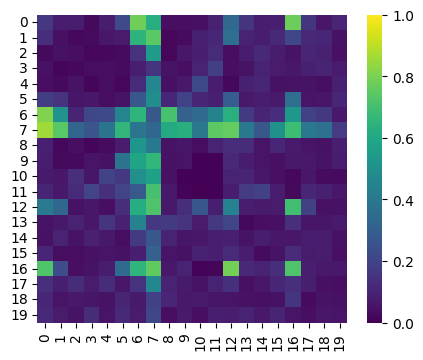

Época [1/1000] | Loss Treino: 2.9997 - Acc Treino: 0.0486 | Loss Val: 2.9976 - Acc Val: 0.0404


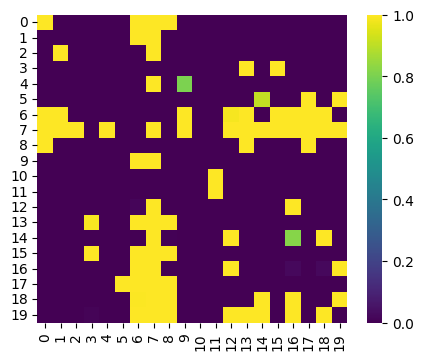

Época [11/1000] | Loss Treino: 1.7473 - Acc Treino: 0.4338 | Loss Val: 1.7312 - Acc Val: 0.4394


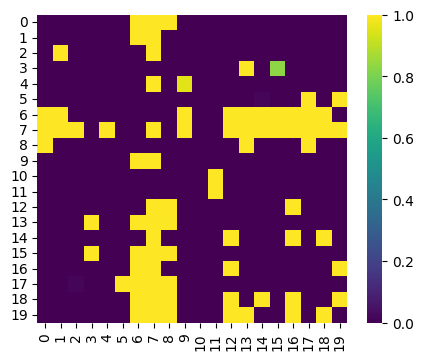

Época [21/1000] | Loss Treino: 1.5962 - Acc Treino: 0.4833 | Loss Val: 1.6256 - Acc Val: 0.4884


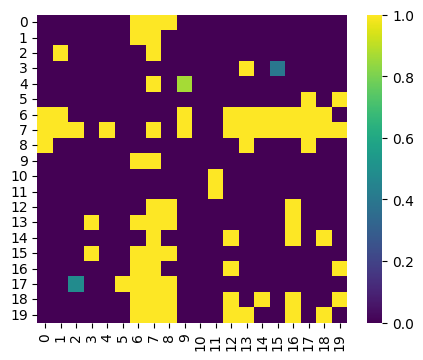

Época [31/1000] | Loss Treino: 1.5182 - Acc Treino: 0.5130 | Loss Val: 1.6487 - Acc Val: 0.4910


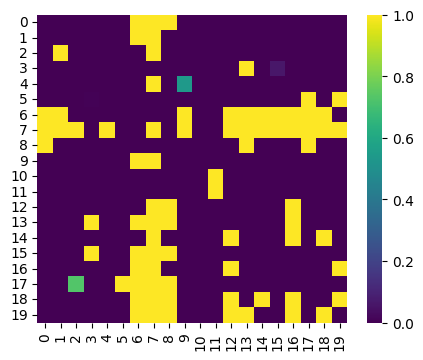

Época [41/1000] | Loss Treino: 1.4722 - Acc Treino: 0.5270 | Loss Val: 1.5582 - Acc Val: 0.5090


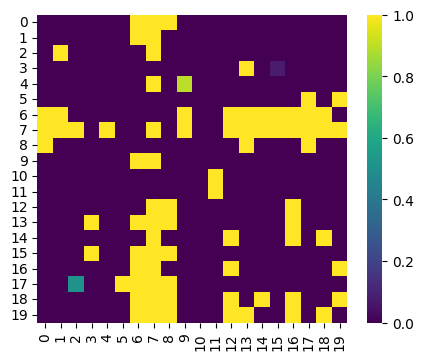

Época [51/1000] | Loss Treino: 1.4373 - Acc Treino: 0.5338 | Loss Val: 1.5473 - Acc Val: 0.5064


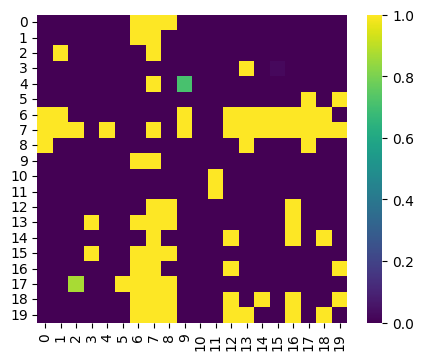

Época [61/1000] | Loss Treino: 1.4195 - Acc Treino: 0.5414 | Loss Val: 1.4961 - Acc Val: 0.5357


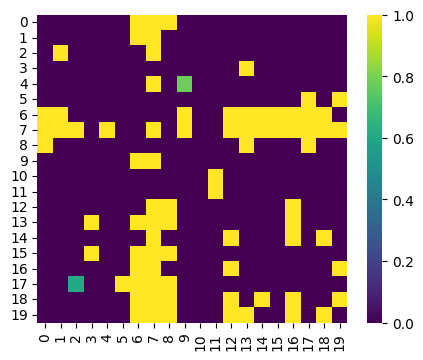

Época [71/1000] | Loss Treino: 1.4038 - Acc Treino: 0.5480 | Loss Val: 1.5268 - Acc Val: 0.5262


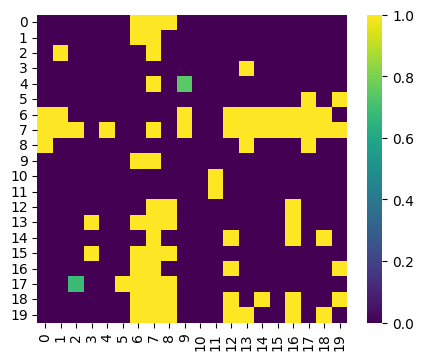

Época [81/1000] | Loss Treino: 1.3717 - Acc Treino: 0.5611 | Loss Val: 1.5046 - Acc Val: 0.5322


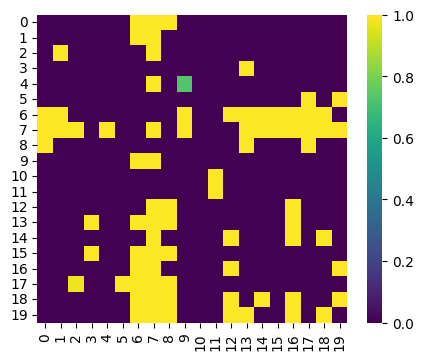

Época [91/1000] | Loss Treino: 1.3624 - Acc Treino: 0.5705 | Loss Val: 1.5499 - Acc Val: 0.5099


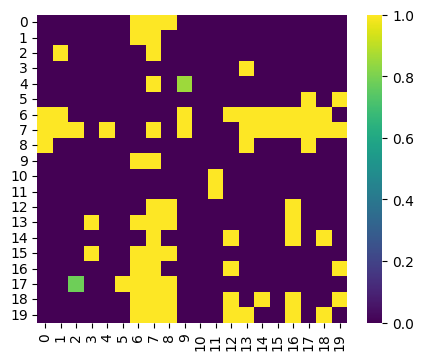

Época [101/1000] | Loss Treino: 1.3445 - Acc Treino: 0.5672 | Loss Val: 1.5262 - Acc Val: 0.5374


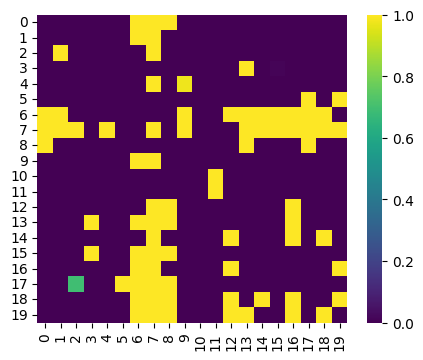

Época [111/1000] | Loss Treino: 1.3456 - Acc Treino: 0.5716 | Loss Val: 1.5018 - Acc Val: 0.5417


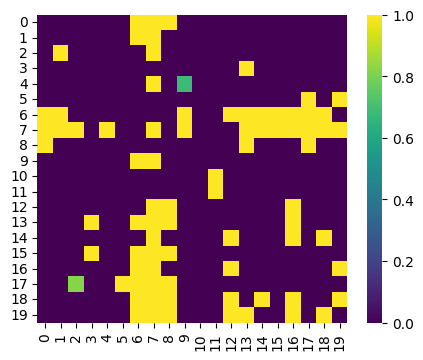

Época [121/1000] | Loss Treino: 1.3323 - Acc Treino: 0.5740 | Loss Val: 1.5018 - Acc Val: 0.5443


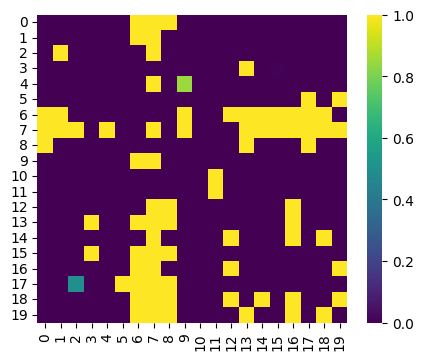

Época [131/1000] | Loss Treino: 1.3113 - Acc Treino: 0.5826 | Loss Val: 1.5546 - Acc Val: 0.5460


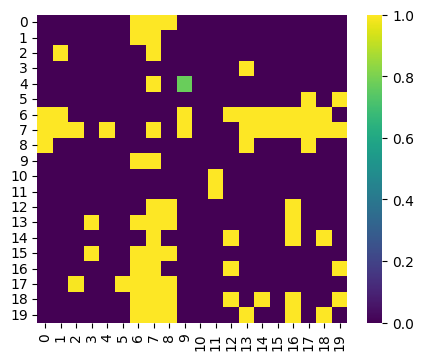

Época [141/1000] | Loss Treino: 1.3066 - Acc Treino: 0.5804 | Loss Val: 1.5721 - Acc Val: 0.5133


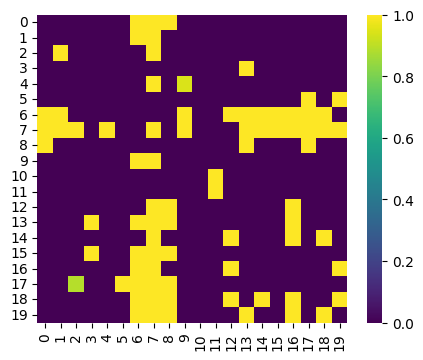

Época [151/1000] | Loss Treino: 1.3006 - Acc Treino: 0.5802 | Loss Val: 1.5158 - Acc Val: 0.5340


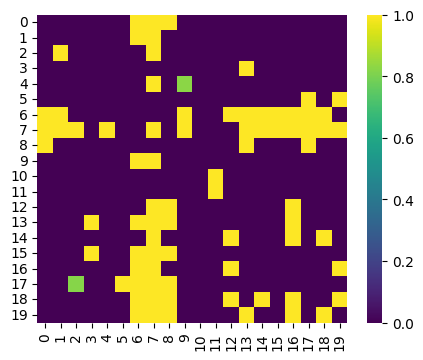

Época [161/1000] | Loss Treino: 1.2921 - Acc Treino: 0.5830 | Loss Val: 1.5115 - Acc Val: 0.5434


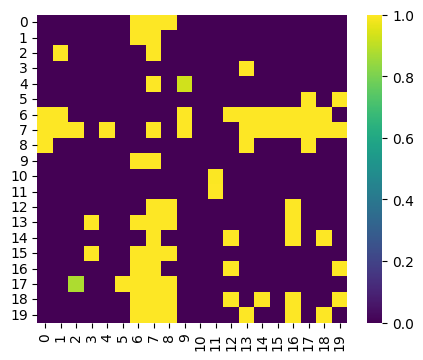

Época [171/1000] | Loss Treino: 1.2854 - Acc Treino: 0.5872 | Loss Val: 1.5788 - Acc Val: 0.5099


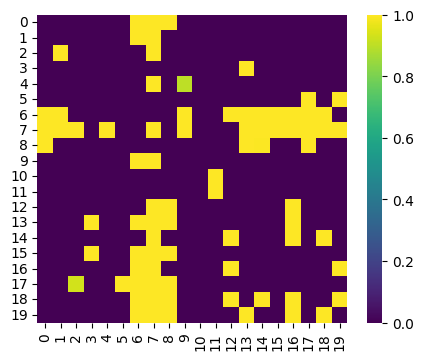

Época [181/1000] | Loss Treino: 1.2799 - Acc Treino: 0.5867 | Loss Val: 1.5139 - Acc Val: 0.5494


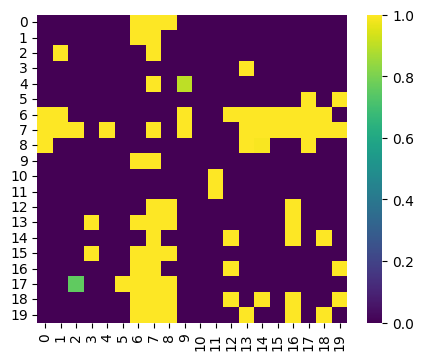

Época [191/1000] | Loss Treino: 1.2729 - Acc Treino: 0.5889 | Loss Val: 1.5243 - Acc Val: 0.5486


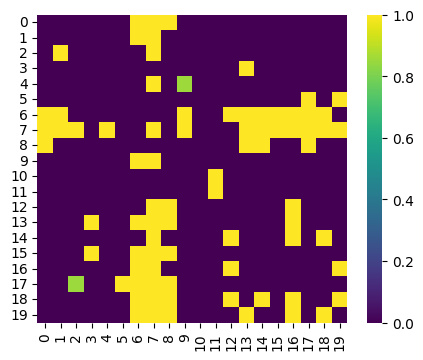

Época [201/1000] | Loss Treino: 1.2558 - Acc Treino: 0.5974 | Loss Val: 1.5065 - Acc Val: 0.5365


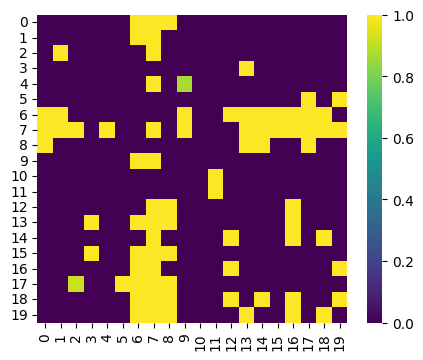

Época [211/1000] | Loss Treino: 1.2514 - Acc Treino: 0.5930 | Loss Val: 1.4961 - Acc Val: 0.5503


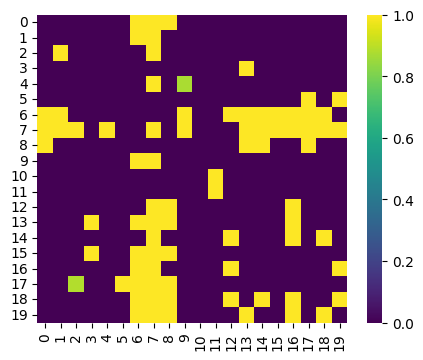

Época [221/1000] | Loss Treino: 1.2502 - Acc Treino: 0.5996 | Loss Val: 1.5350 - Acc Val: 0.5383


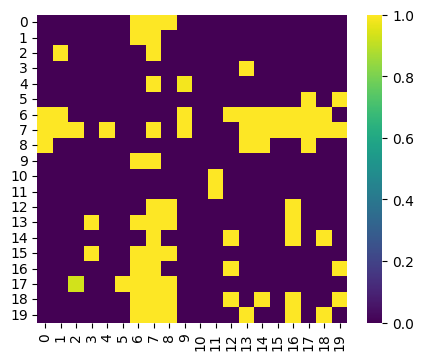

Época [231/1000] | Loss Treino: 1.2466 - Acc Treino: 0.5948 | Loss Val: 1.5204 - Acc Val: 0.5494


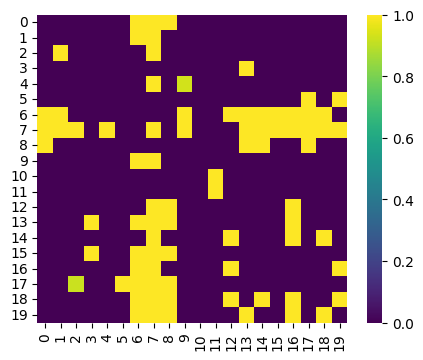

Época [241/1000] | Loss Treino: 1.2441 - Acc Treino: 0.5974 | Loss Val: 1.5170 - Acc Val: 0.5357


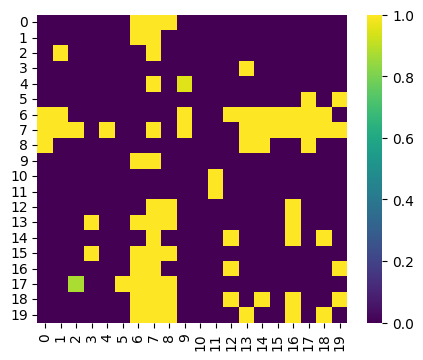

Época [251/1000] | Loss Treino: 1.2344 - Acc Treino: 0.5992 | Loss Val: 1.4796 - Acc Val: 0.5520


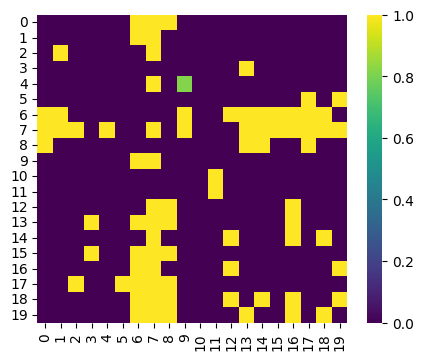

Época [261/1000] | Loss Treino: 1.2264 - Acc Treino: 0.6007 | Loss Val: 1.4940 - Acc Val: 0.5512


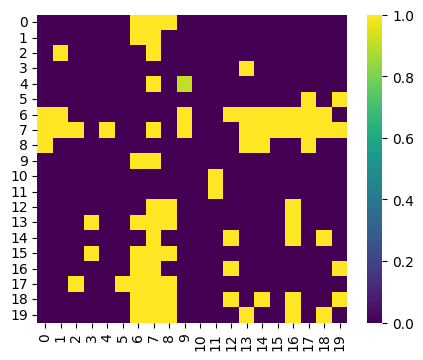

Época [271/1000] | Loss Treino: 1.2108 - Acc Treino: 0.6049 | Loss Val: 1.5020 - Acc Val: 0.5546


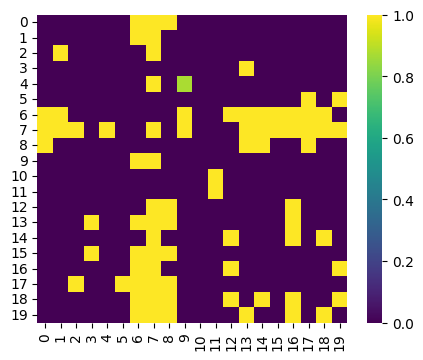

Época [281/1000] | Loss Treino: 1.2147 - Acc Treino: 0.6068 | Loss Val: 1.4716 - Acc Val: 0.5666


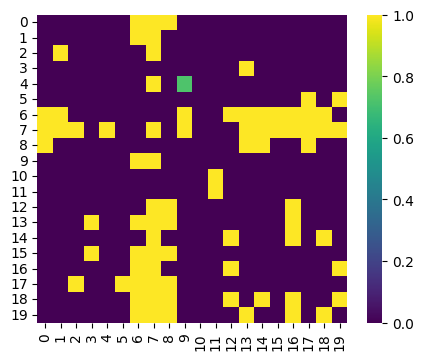

Época [291/1000] | Loss Treino: 1.2102 - Acc Treino: 0.6035 | Loss Val: 1.5482 - Acc Val: 0.5520


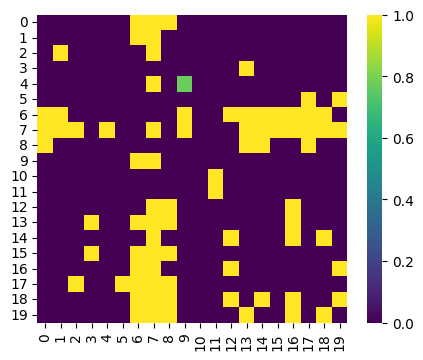

Época [301/1000] | Loss Treino: 1.2024 - Acc Treino: 0.6136 | Loss Val: 1.5021 - Acc Val: 0.5451


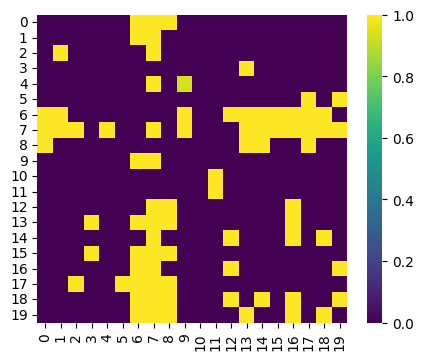

Época [311/1000] | Loss Treino: 1.2112 - Acc Treino: 0.6051 | Loss Val: 1.5543 - Acc Val: 0.5460


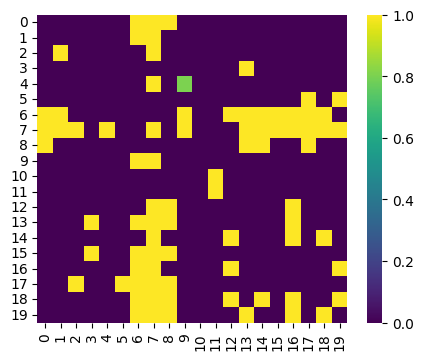

Época [321/1000] | Loss Treino: 1.1963 - Acc Treino: 0.6095 | Loss Val: 1.5101 - Acc Val: 0.5649


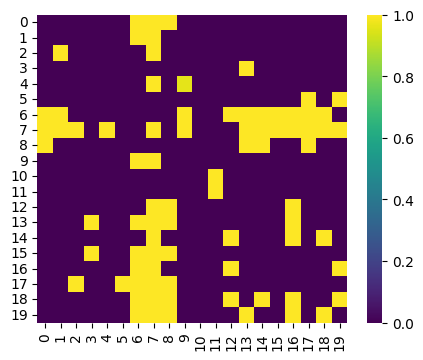

Época [331/1000] | Loss Treino: 1.1873 - Acc Treino: 0.6173 | Loss Val: 1.5229 - Acc Val: 0.5658


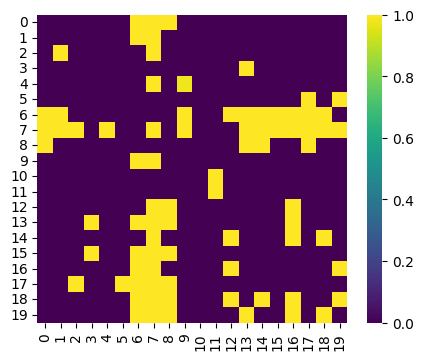

Época [341/1000] | Loss Treino: 1.2016 - Acc Treino: 0.6042 | Loss Val: 1.4982 - Acc Val: 0.5417


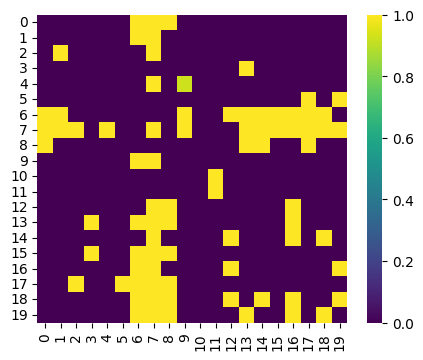

Época [351/1000] | Loss Treino: 1.1926 - Acc Treino: 0.6118 | Loss Val: 1.5043 - Acc Val: 0.5460


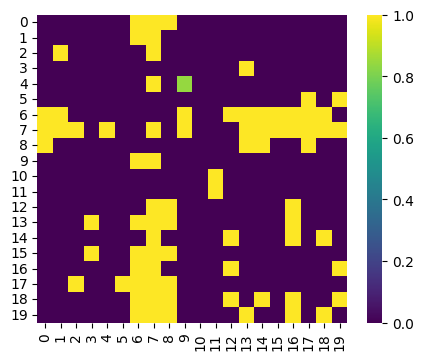

Época [361/1000] | Loss Treino: 1.1846 - Acc Treino: 0.6129 | Loss Val: 1.5363 - Acc Val: 0.5477


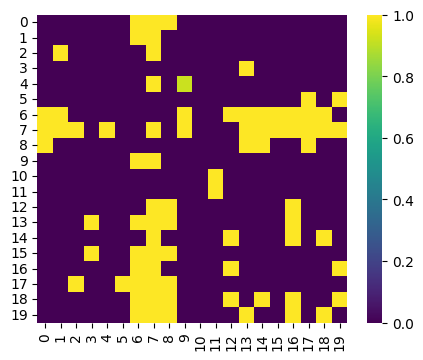

Época [371/1000] | Loss Treino: 1.1686 - Acc Treino: 0.6206 | Loss Val: 1.5068 - Acc Val: 0.5469


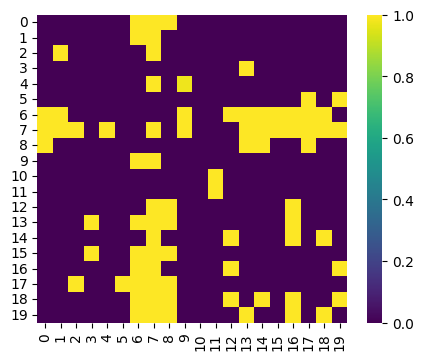

Época [381/1000] | Loss Treino: 1.1709 - Acc Treino: 0.6119 | Loss Val: 1.5172 - Acc Val: 0.5520


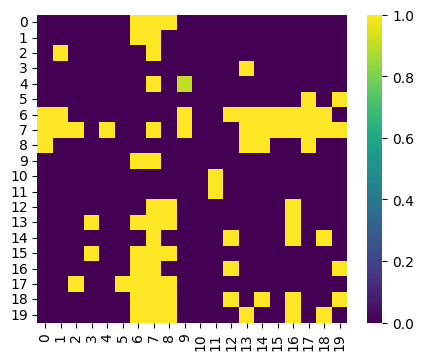

Época [391/1000] | Loss Treino: 1.1667 - Acc Treino: 0.6167 | Loss Val: 1.5418 - Acc Val: 0.5417


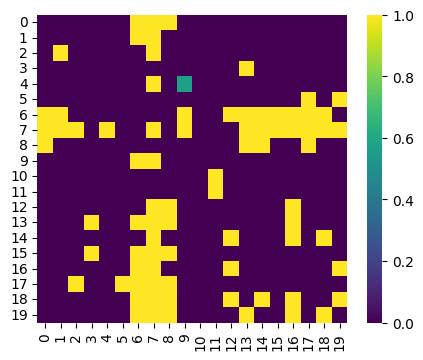

Época [401/1000] | Loss Treino: 1.1743 - Acc Treino: 0.6167 | Loss Val: 1.6007 - Acc Val: 0.5520


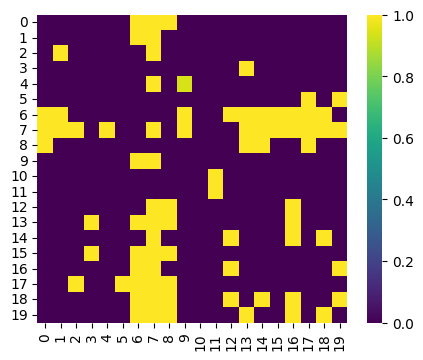

Época [411/1000] | Loss Treino: 1.1770 - Acc Treino: 0.6153 | Loss Val: 1.4995 - Acc Val: 0.5563


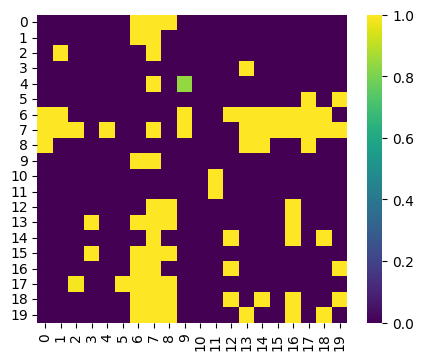

Época [421/1000] | Loss Treino: 1.1691 - Acc Treino: 0.6171 | Loss Val: 1.5004 - Acc Val: 0.5529


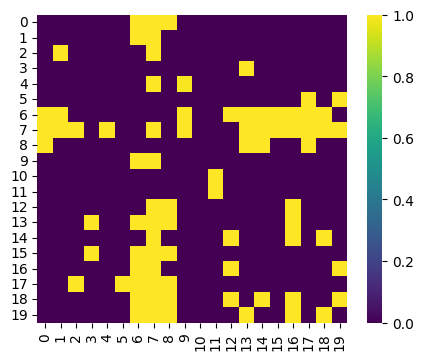

Época [431/1000] | Loss Treino: 1.1712 - Acc Treino: 0.6215 | Loss Val: 1.4969 - Acc Val: 0.5598


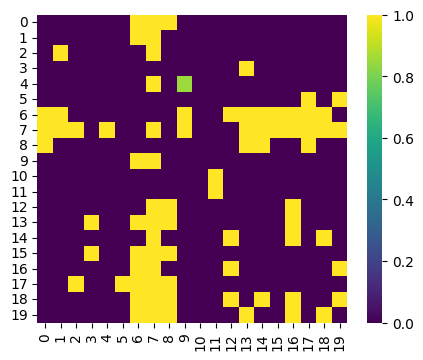

Época [441/1000] | Loss Treino: 1.1635 - Acc Treino: 0.6210 | Loss Val: 1.4907 - Acc Val: 0.5520


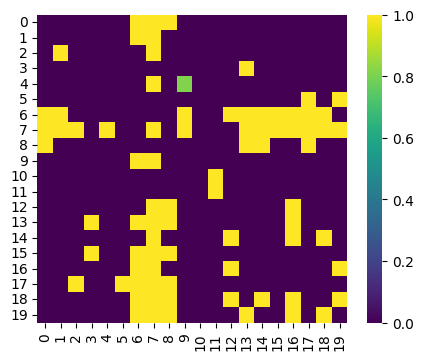

Época [451/1000] | Loss Treino: 1.1597 - Acc Treino: 0.6226 | Loss Val: 1.5466 - Acc Val: 0.5589


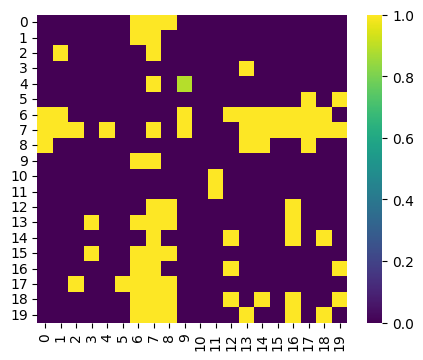

Época [461/1000] | Loss Treino: 1.1512 - Acc Treino: 0.6250 | Loss Val: 1.5269 - Acc Val: 0.5443


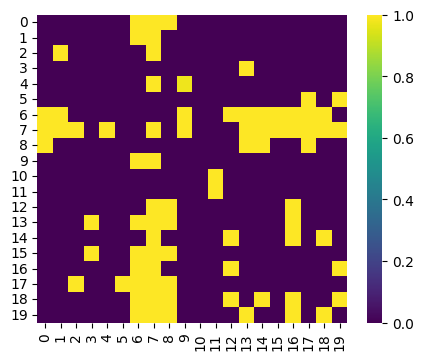

Época [471/1000] | Loss Treino: 1.1524 - Acc Treino: 0.6256 | Loss Val: 1.5324 - Acc Val: 0.5598


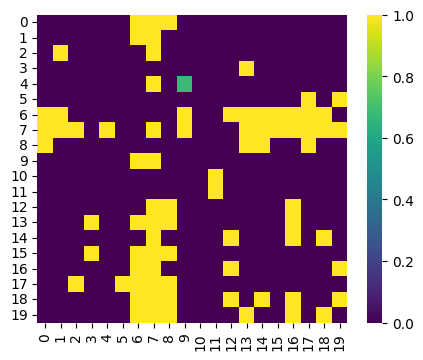

Época [481/1000] | Loss Treino: 1.1507 - Acc Treino: 0.6197 | Loss Val: 1.5301 - Acc Val: 0.5623


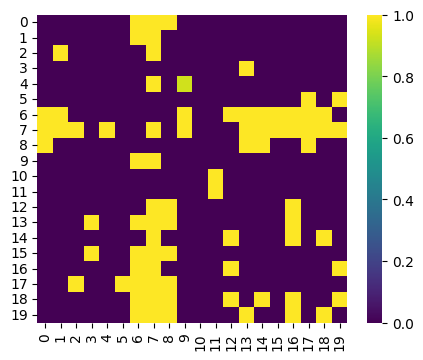

Época [491/1000] | Loss Treino: 1.1523 - Acc Treino: 0.6223 | Loss Val: 1.5510 - Acc Val: 0.5503


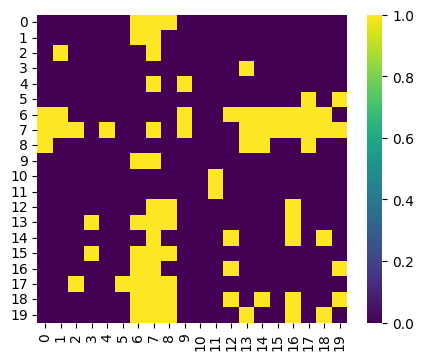

Época [501/1000] | Loss Treino: 1.1333 - Acc Treino: 0.6289 | Loss Val: 1.5637 - Acc Val: 0.5520


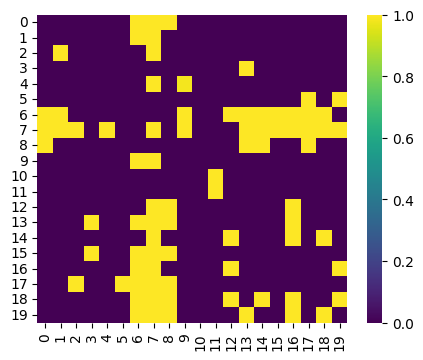

Época [511/1000] | Loss Treino: 1.1524 - Acc Treino: 0.6215 | Loss Val: 1.4924 - Acc Val: 0.5615


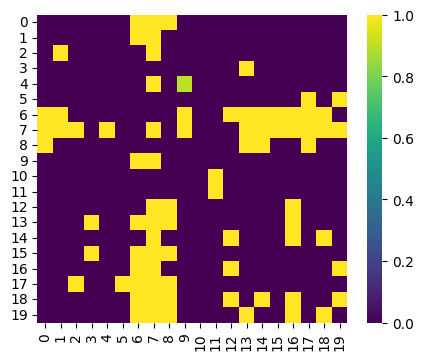

Época [521/1000] | Loss Treino: 1.1412 - Acc Treino: 0.6282 | Loss Val: 1.5049 - Acc Val: 0.5718


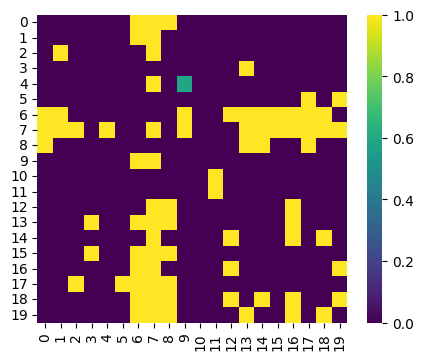

Época [531/1000] | Loss Treino: 1.1369 - Acc Treino: 0.6267 | Loss Val: 1.5591 - Acc Val: 0.5520


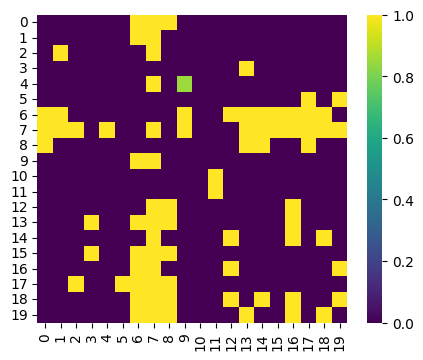

Época [541/1000] | Loss Treino: 1.1410 - Acc Treino: 0.6298 | Loss Val: 1.5561 - Acc Val: 0.5503


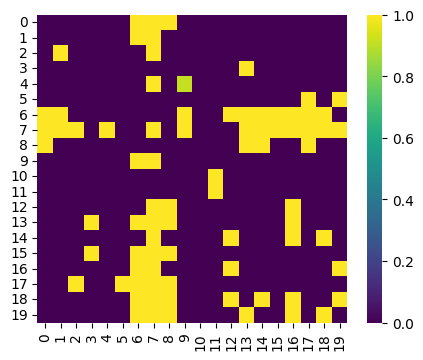

Época [551/1000] | Loss Treino: 1.1426 - Acc Treino: 0.6276 | Loss Val: 1.5173 - Acc Val: 0.5649


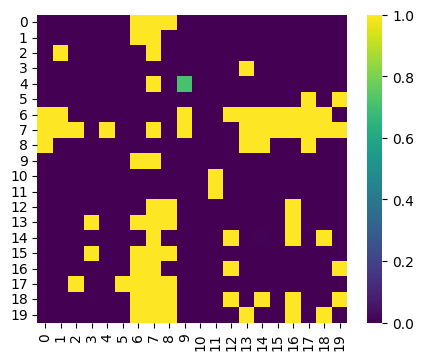

Época [561/1000] | Loss Treino: 1.1205 - Acc Treino: 0.6329 | Loss Val: 1.5281 - Acc Val: 0.5658


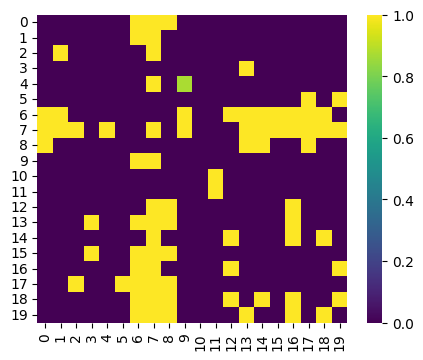

Época [571/1000] | Loss Treino: 1.1220 - Acc Treino: 0.6322 | Loss Val: 1.4808 - Acc Val: 0.5761


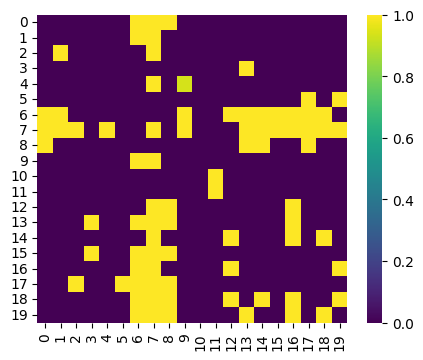

Época [581/1000] | Loss Treino: 1.1392 - Acc Treino: 0.6309 | Loss Val: 1.5554 - Acc Val: 0.5675


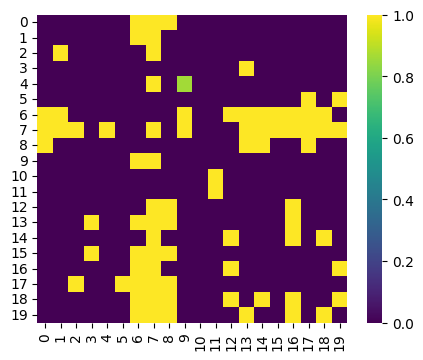

Época [591/1000] | Loss Treino: 1.1293 - Acc Treino: 0.6289 | Loss Val: 1.4962 - Acc Val: 0.5718


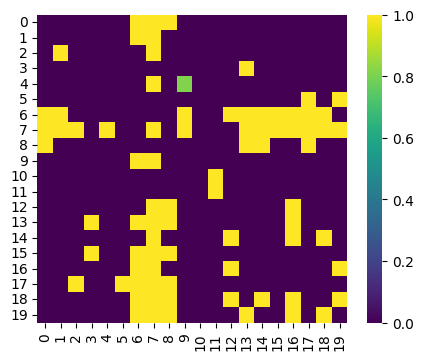

Época [601/1000] | Loss Treino: 1.1349 - Acc Treino: 0.6248 | Loss Val: 1.5706 - Acc Val: 0.5537


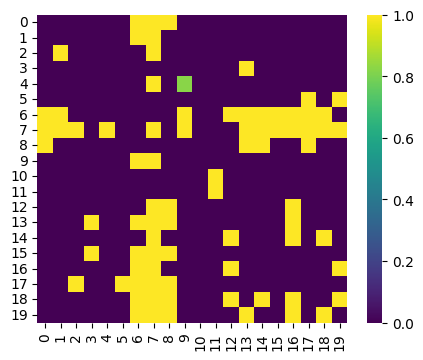

Época [611/1000] | Loss Treino: 1.1405 - Acc Treino: 0.6261 | Loss Val: 1.5139 - Acc Val: 0.5520


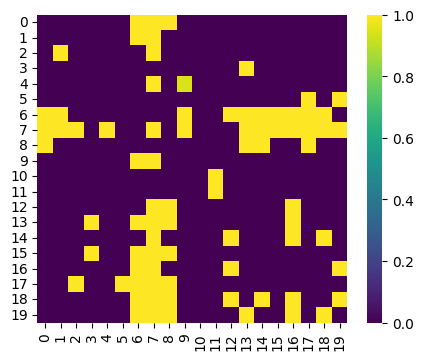

Época [621/1000] | Loss Treino: 1.1207 - Acc Treino: 0.6329 | Loss Val: 1.5217 - Acc Val: 0.5658


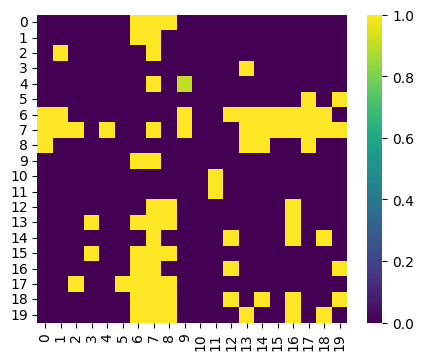

Época [631/1000] | Loss Treino: 1.1328 - Acc Treino: 0.6289 | Loss Val: 1.5058 - Acc Val: 0.5675


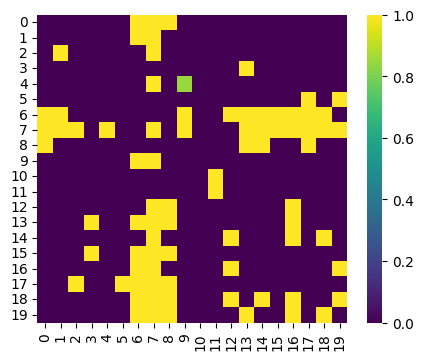

Época [641/1000] | Loss Treino: 1.1326 - Acc Treino: 0.6337 | Loss Val: 1.5437 - Acc Val: 0.5520


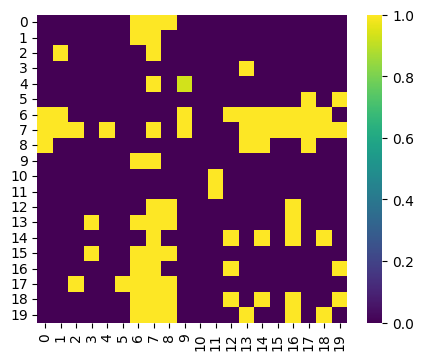

Época [651/1000] | Loss Treino: 1.1163 - Acc Treino: 0.6376 | Loss Val: 1.5679 - Acc Val: 0.5512


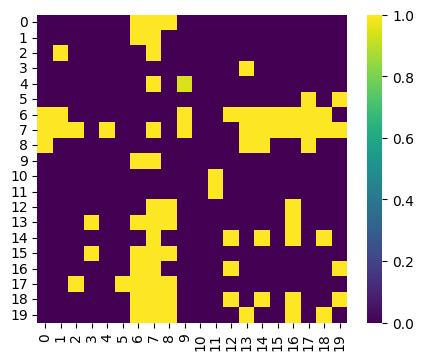

Época [661/1000] | Loss Treino: 1.1135 - Acc Treino: 0.6282 | Loss Val: 1.5312 - Acc Val: 0.5787


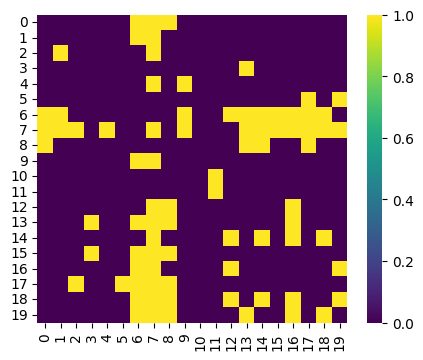

Época [671/1000] | Loss Treino: 1.1092 - Acc Treino: 0.6329 | Loss Val: 1.5412 - Acc Val: 0.5623


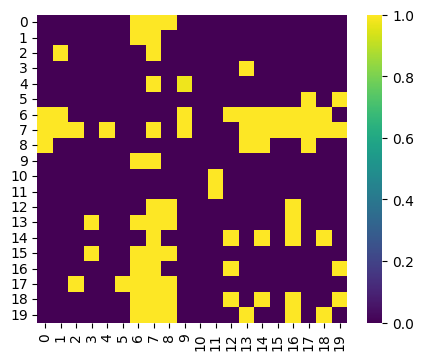

Época [681/1000] | Loss Treino: 1.1117 - Acc Treino: 0.6280 | Loss Val: 1.5709 - Acc Val: 0.5658


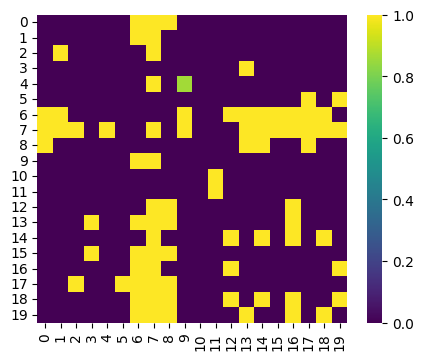

Época [691/1000] | Loss Treino: 1.1244 - Acc Treino: 0.6372 | Loss Val: 1.6128 - Acc Val: 0.5460


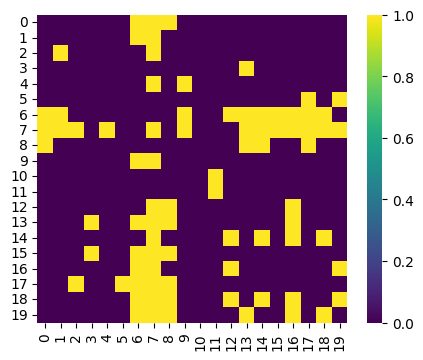

Época [701/1000] | Loss Treino: 1.1099 - Acc Treino: 0.6337 | Loss Val: 1.5235 - Acc Val: 0.5684


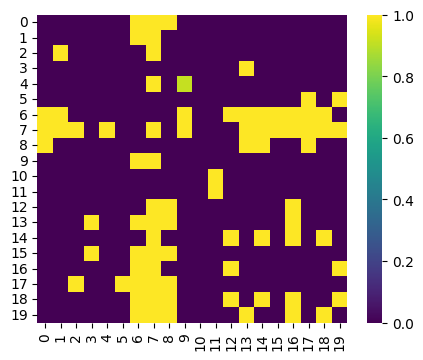

Época [711/1000] | Loss Treino: 1.1158 - Acc Treino: 0.6357 | Loss Val: 1.5265 - Acc Val: 0.5701


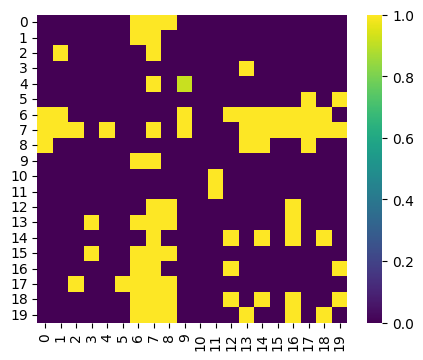

Época [721/1000] | Loss Treino: 1.1224 - Acc Treino: 0.6306 | Loss Val: 1.5398 - Acc Val: 0.5606


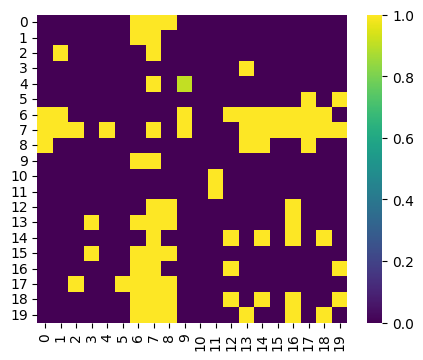

Época [731/1000] | Loss Treino: 1.1189 - Acc Treino: 0.6368 | Loss Val: 1.4989 - Acc Val: 0.5752


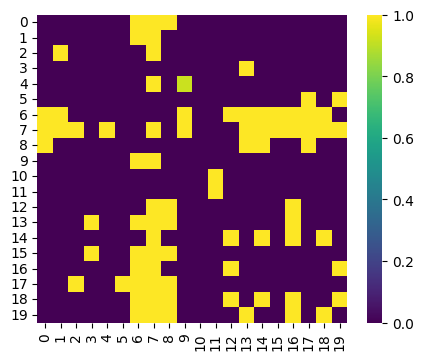

Época [741/1000] | Loss Treino: 1.1040 - Acc Treino: 0.6344 | Loss Val: 1.5482 - Acc Val: 0.5684


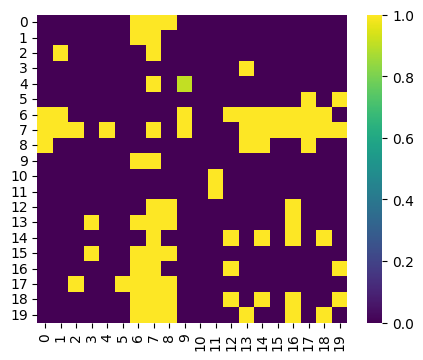

Época [751/1000] | Loss Treino: 1.1194 - Acc Treino: 0.6296 | Loss Val: 1.5643 - Acc Val: 0.5752


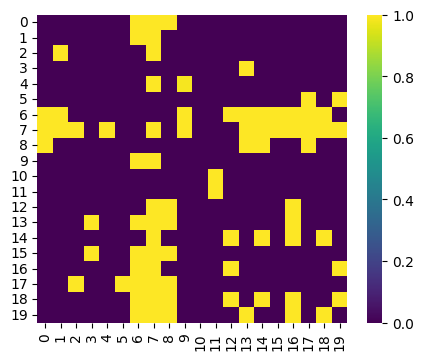

Época [761/1000] | Loss Treino: 1.1167 - Acc Treino: 0.6291 | Loss Val: 1.5353 - Acc Val: 0.5692


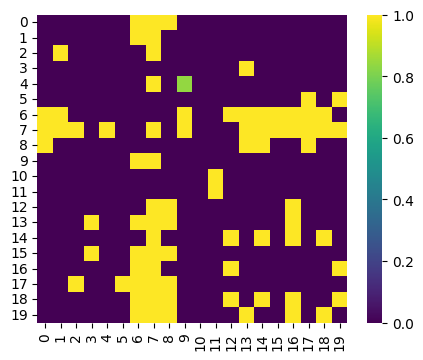

Época [771/1000] | Loss Treino: 1.1103 - Acc Treino: 0.6333 | Loss Val: 1.5638 - Acc Val: 0.5778


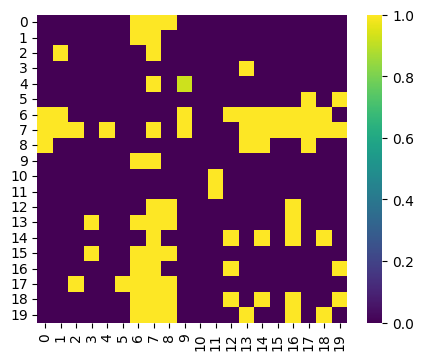

Época [781/1000] | Loss Treino: 1.1079 - Acc Treino: 0.6361 | Loss Val: 1.5192 - Acc Val: 0.5735


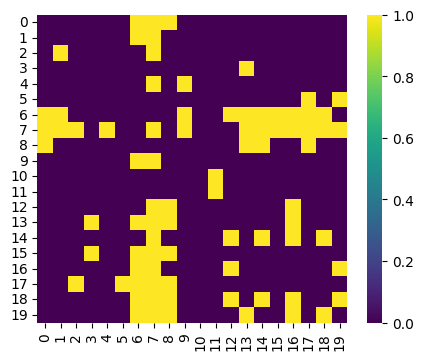

Época [791/1000] | Loss Treino: 1.1027 - Acc Treino: 0.6438 | Loss Val: 1.5071 - Acc Val: 0.5933


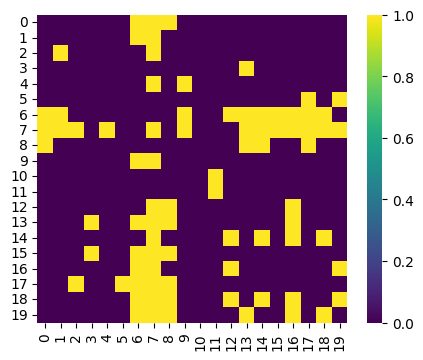

Época [801/1000] | Loss Treino: 1.0998 - Acc Treino: 0.6335 | Loss Val: 1.5335 - Acc Val: 0.5641


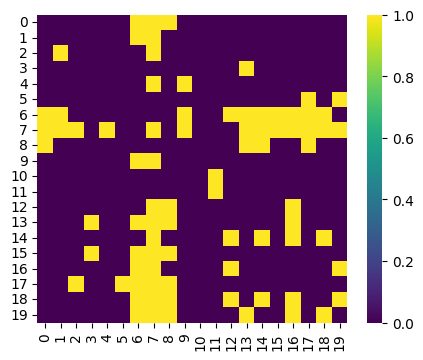

Época [811/1000] | Loss Treino: 1.1046 - Acc Treino: 0.6320 | Loss Val: 1.5316 - Acc Val: 0.5675


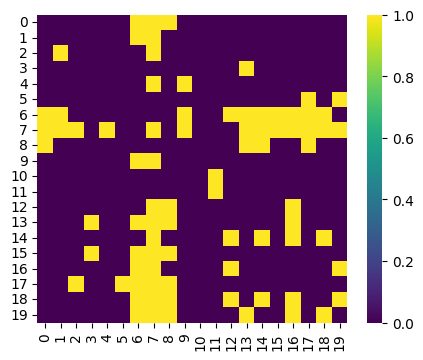

Época [821/1000] | Loss Treino: 1.1106 - Acc Treino: 0.6339 | Loss Val: 1.5310 - Acc Val: 0.5847


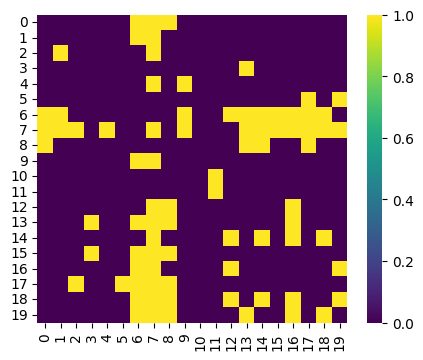

Época [831/1000] | Loss Treino: 1.1122 - Acc Treino: 0.6352 | Loss Val: 1.5679 - Acc Val: 0.5632


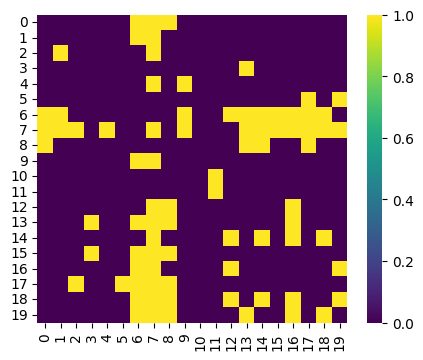

Época [841/1000] | Loss Treino: 1.0981 - Acc Treino: 0.6423 | Loss Val: 1.5534 - Acc Val: 0.5658


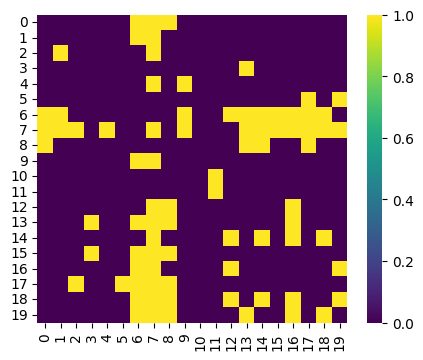

Época [851/1000] | Loss Treino: 1.0997 - Acc Treino: 0.6317 | Loss Val: 1.5688 - Acc Val: 0.5864


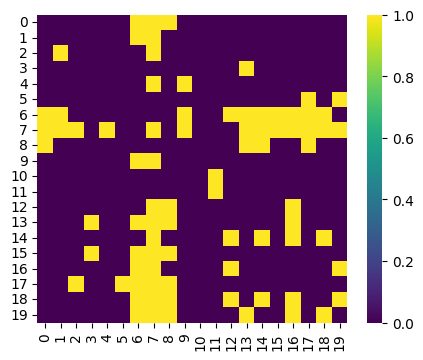

Época [861/1000] | Loss Treino: 1.0924 - Acc Treino: 0.6401 | Loss Val: 1.5435 - Acc Val: 0.5675


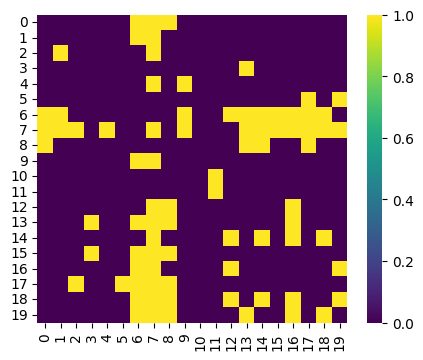

Época [871/1000] | Loss Treino: 1.0956 - Acc Treino: 0.6438 | Loss Val: 1.5213 - Acc Val: 0.5752


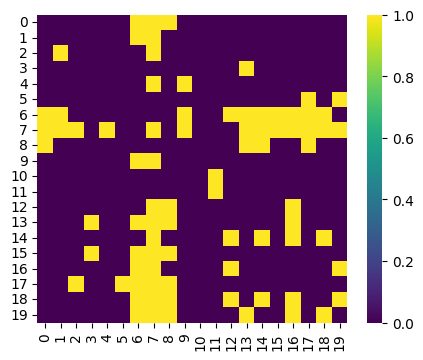

Época [881/1000] | Loss Treino: 1.0832 - Acc Treino: 0.6370 | Loss Val: 1.5819 - Acc Val: 0.5701


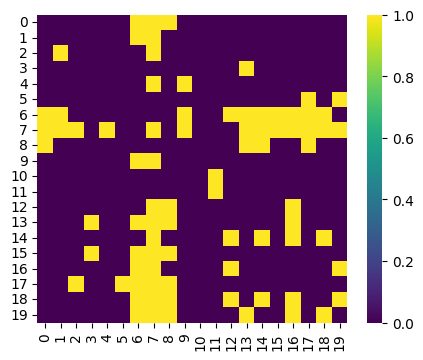

Época [891/1000] | Loss Treino: 1.0956 - Acc Treino: 0.6405 | Loss Val: 1.5830 - Acc Val: 0.5649


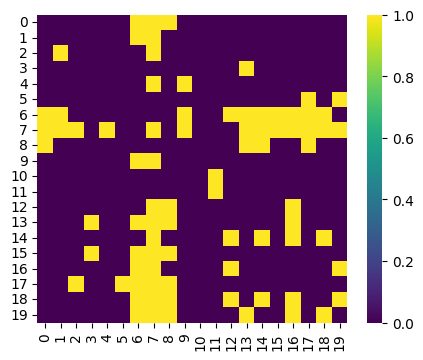

Época [901/1000] | Loss Treino: 1.0908 - Acc Treino: 0.6344 | Loss Val: 1.5606 - Acc Val: 0.5666


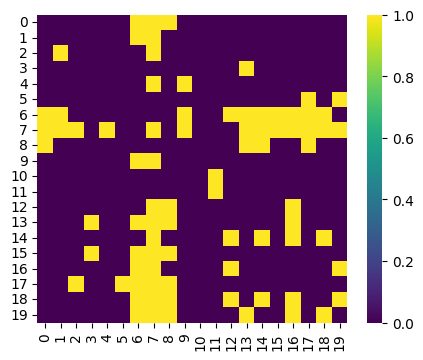

Época [911/1000] | Loss Treino: 1.0856 - Acc Treino: 0.6409 | Loss Val: 1.6062 - Acc Val: 0.5787


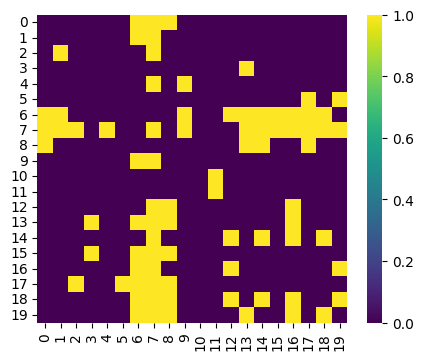

Época [921/1000] | Loss Treino: 1.0858 - Acc Treino: 0.6447 | Loss Val: 1.5926 - Acc Val: 0.5735


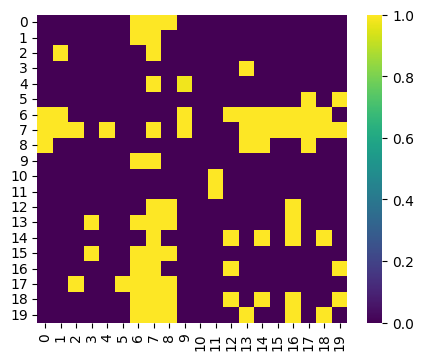

Época [931/1000] | Loss Treino: 1.1053 - Acc Treino: 0.6377 | Loss Val: 1.5663 - Acc Val: 0.5735


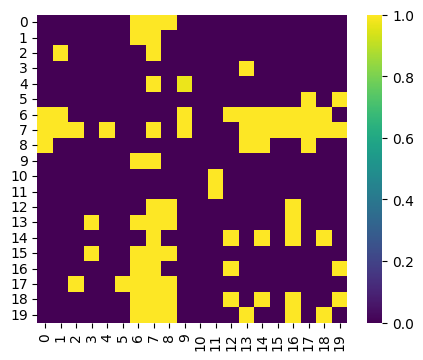

Época [941/1000] | Loss Treino: 1.0895 - Acc Treino: 0.6446 | Loss Val: 1.5710 - Acc Val: 0.5606


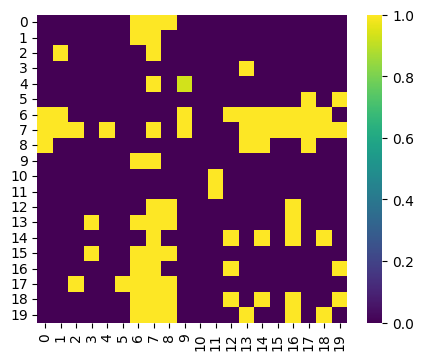

Época [951/1000] | Loss Treino: 1.0870 - Acc Treino: 0.6407 | Loss Val: 1.5990 - Acc Val: 0.5589


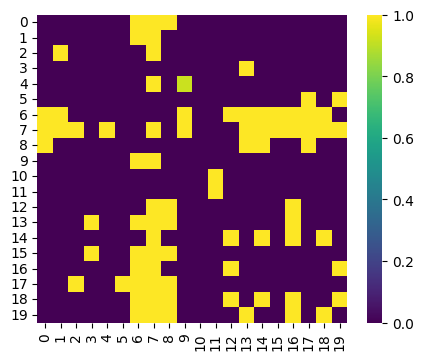

Época [961/1000] | Loss Treino: 1.0941 - Acc Treino: 0.6411 | Loss Val: 1.5717 - Acc Val: 0.5770


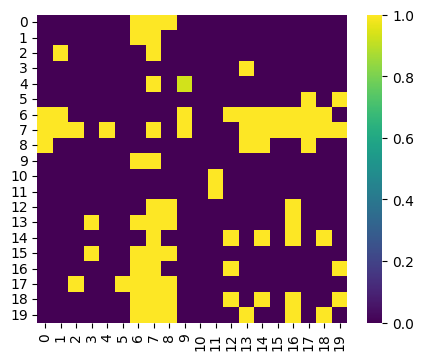

Época [971/1000] | Loss Treino: 1.0837 - Acc Treino: 0.6451 | Loss Val: 1.5576 - Acc Val: 0.5735


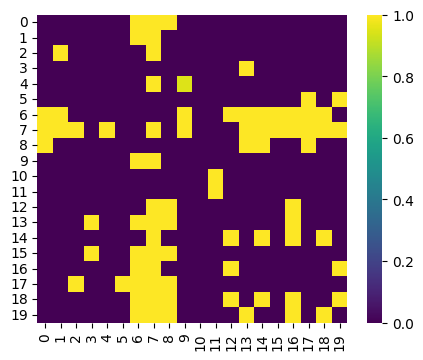

Época [981/1000] | Loss Treino: 1.0737 - Acc Treino: 0.6479 | Loss Val: 1.5723 - Acc Val: 0.5718


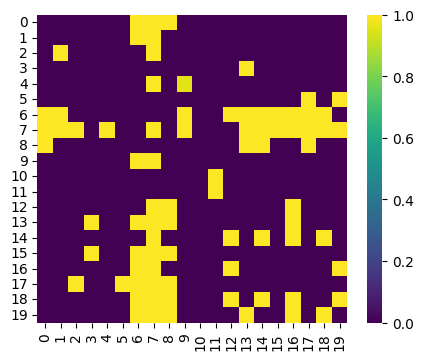

Época [991/1000] | Loss Treino: 1.0786 - Acc Treino: 0.6453 | Loss Val: 1.5573 - Acc Val: 0.5658


In [43]:
import torch.optim as optim
import torch.nn as nn

model = GestureGSLModel(num_nodes=20, in_features=2, num_classes=20)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando na unidade: {device}")

model = model.to(device)

criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epocas = 1000

loss_history = []
val_loss_history = []

for epoca in range(num_epocas):
    loss_media_treino, acc_treino = train(model, loader_treino, optimizer, criterion, device)
    
    loss_media_val, acc_val = evaluate(model, loader_val, criterion, device)
    
    loss_history.append(loss_media_treino)
    val_loss_history.append(loss_media_val)
    
    if epoca % 10 == 0 or epoca == 0:
        adj = sharp_sigmoid(model.adj_param,30,0.1).detach().cpu().numpy()
        plt.figure(figsize=(5, 4))
        sns.heatmap(adj, cmap="viridis", vmin=0, vmax=1)
        plt.show()
        print(f"Época [{epoca+1}/{num_epocas}] | "
            f"Loss Treino: {loss_media_treino:.4f} - Acc Treino: {acc_treino:.4f} | "
            f"Loss Val: {loss_media_val:.4f} - Acc Val: {acc_val:.4f}")


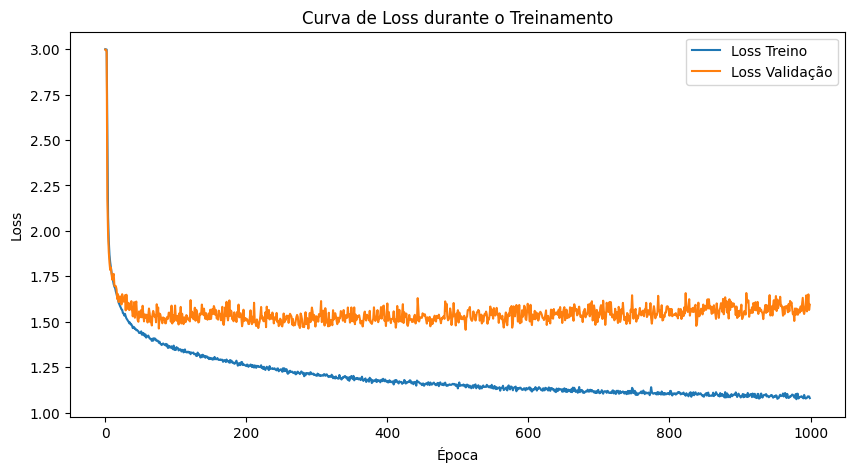

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss Treino')
plt.plot(val_loss_history, label='Loss Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de Loss durante o Treinamento')
plt.legend()
plt.show()

In [ ]:
test_loss,test_acc = evaluate(model,loader_teste,criterion,"cuda")
print(f"Acc test: {test_acc}")

Acc test 0.5781786941580757


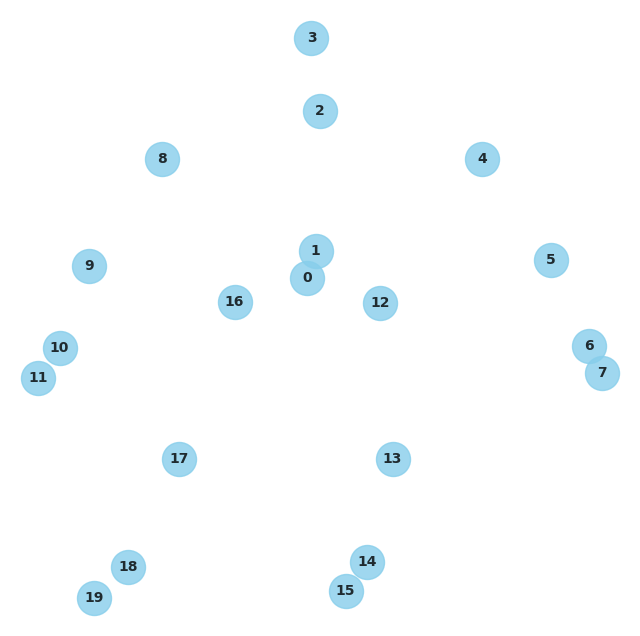

In [ ]:
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data 
from torch_geometric.utils import to_networkx

model.eval()
adj_aprendida = sharp_sigmoid(model.adj_param,30,0.1).detach().cpu()

limiar = 0.9
adj_filtrada = torch.where(adj_aprendida > limiar, torch.tensor(1.0), torch.tensor(0.0))

edge_index, _ = dense_to_sparse(adj_filtrada)
data_view = Data(edge_index=edge_index, num_nodes=20)
G = to_networkx(data_view, to_undirected=True)

amostra_base = dataset_teste[0]
coordenadas_reais = amostra_base.x[0].numpy()

posicoes_esqueleto = {i: (coordenadas_reais[i, 0], coordenadas_reais[i, 1]) for i in range(20)}

plt.figure(figsize=(8, 8))
plt.axis('off')

nx.draw_networkx(
    G,
    pos=posicoes_esqueleto, 
    with_labels=True,
    node_size=600,
    node_color="skyblue",
    font_size=10,
    font_weight="bold",
    edge_color="red",     
    width=1.0,            
    alpha=0.8
)

plt.gca().invert_yaxis()
plt.show()